In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [5]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [6]:
df.head(10)

NameError: name 'df' is not defined

In [7]:
df = pd.read_csv('netflix_titles.csv')
print("Dataset carregado!")

Dataset carregado!


In [8]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [9]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print("\nTipos de dados:")
print(df.dtypes)

Linhas: 8807
Colunas: 12

Tipos de dados:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [11]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [12]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


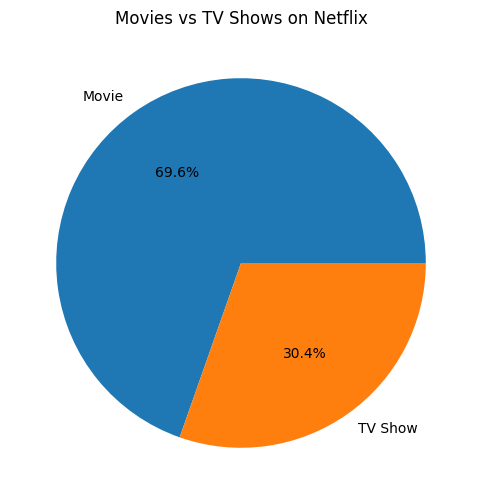

In [13]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('')
plt.show()

In [14]:
df['year_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce').dt.year
df['year_added'].value_counts().sort_index()

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,11
2014.0,24
2015.0,82
2016.0,429


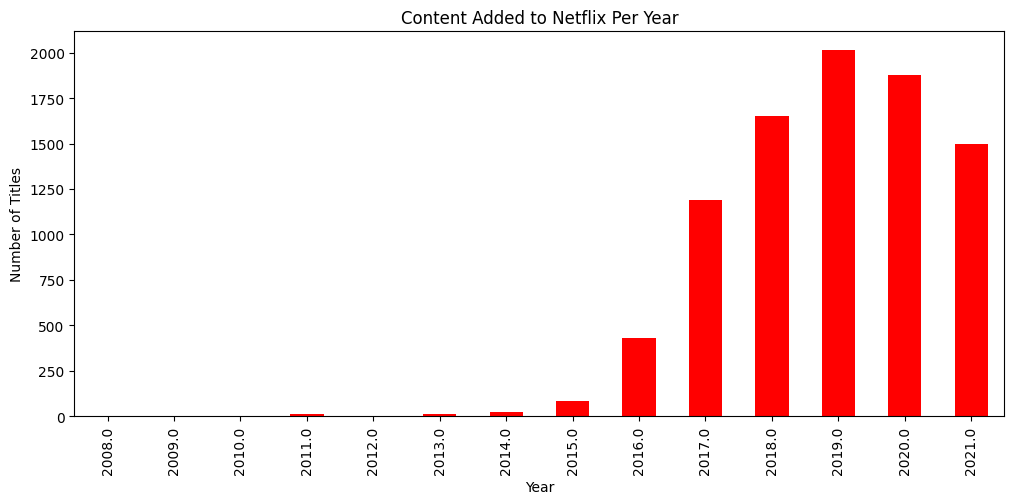

In [15]:
df['year_added'].value_counts().sort_index().plot(kind='bar', figsize=(12,5), color='red')
plt.title('Content Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

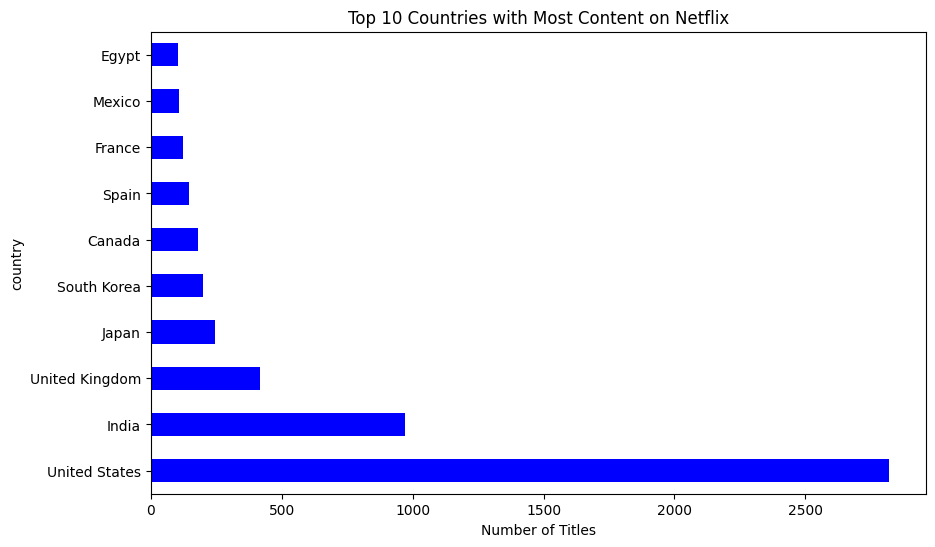

In [17]:
df['country'].value_counts().head(10).plot(kind='barh', figsize=(10,6), color='blue')
plt.title('Top 10 Countries with Most Content on Netflix')
plt.xlabel('Number of Titles')
plt.show()

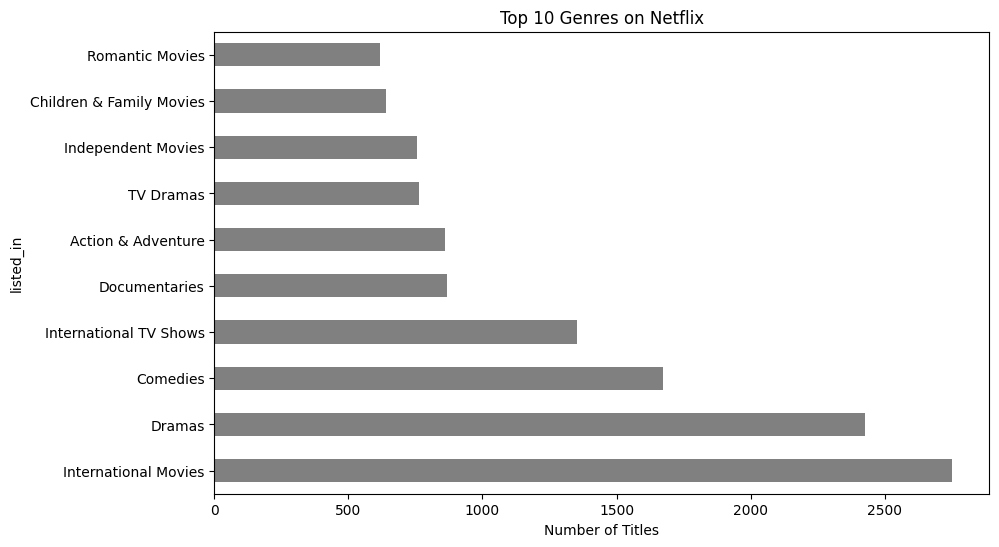

In [19]:
genres = df['listed_in'].str.split(', ').explode()
genres.value_counts().head(10).plot(kind='barh', figsize=(10,6), color='grey')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.show()

In [21]:
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

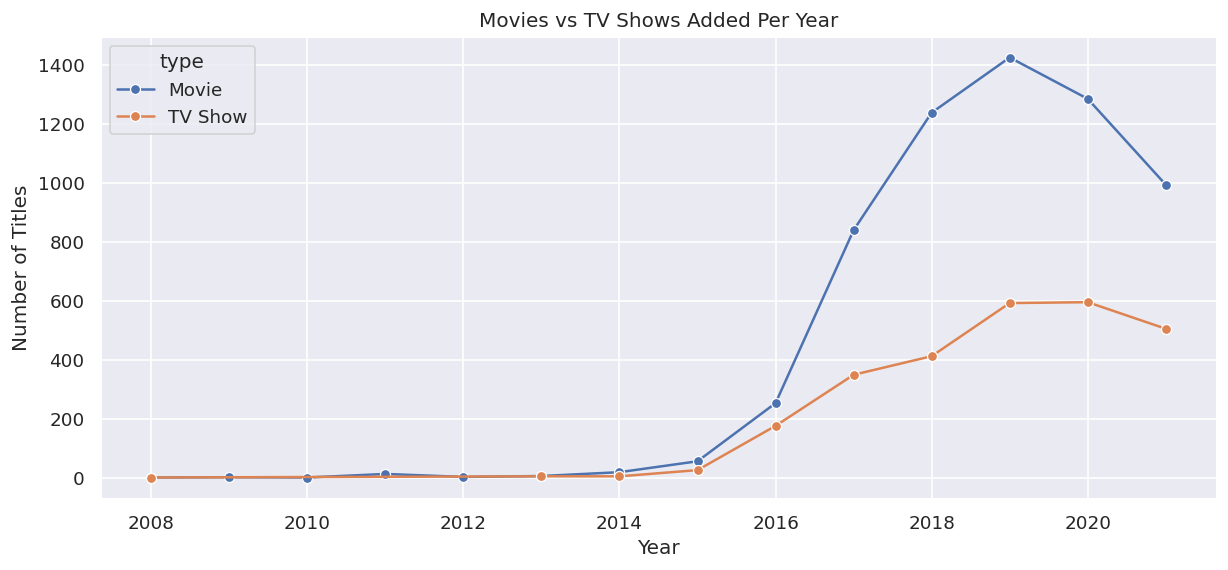

In [22]:
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(12,5))
sns.lineplot(data=yearly, x='year_added', y='count', hue='type', marker='o')
plt.title('Movies vs TV Shows Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

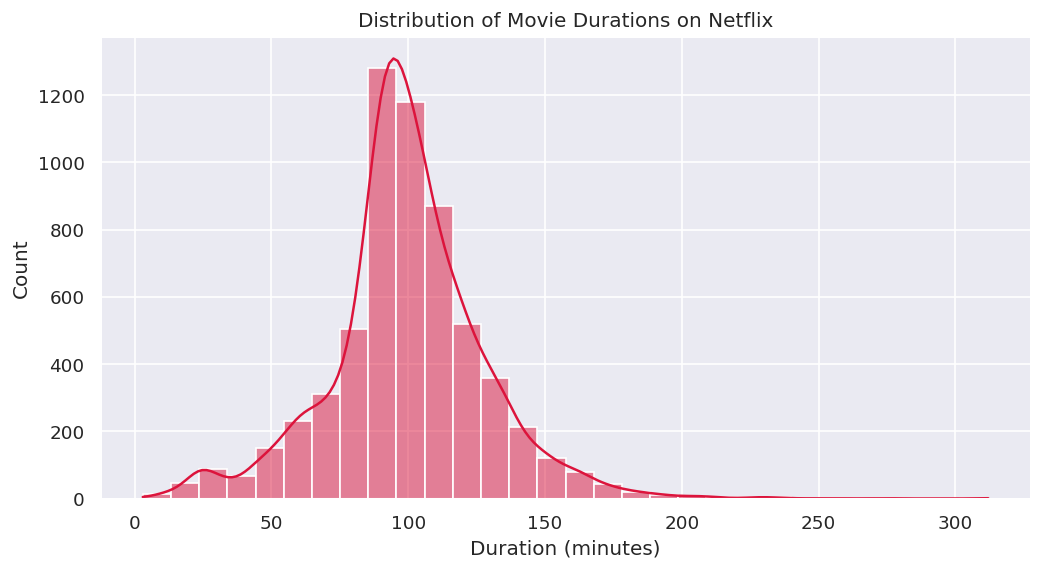

In [23]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(10,5))
sns.histplot(movies['duration_min'].dropna(), bins=30, color='crimson', kde=True)
plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (minutes)')
plt.show()

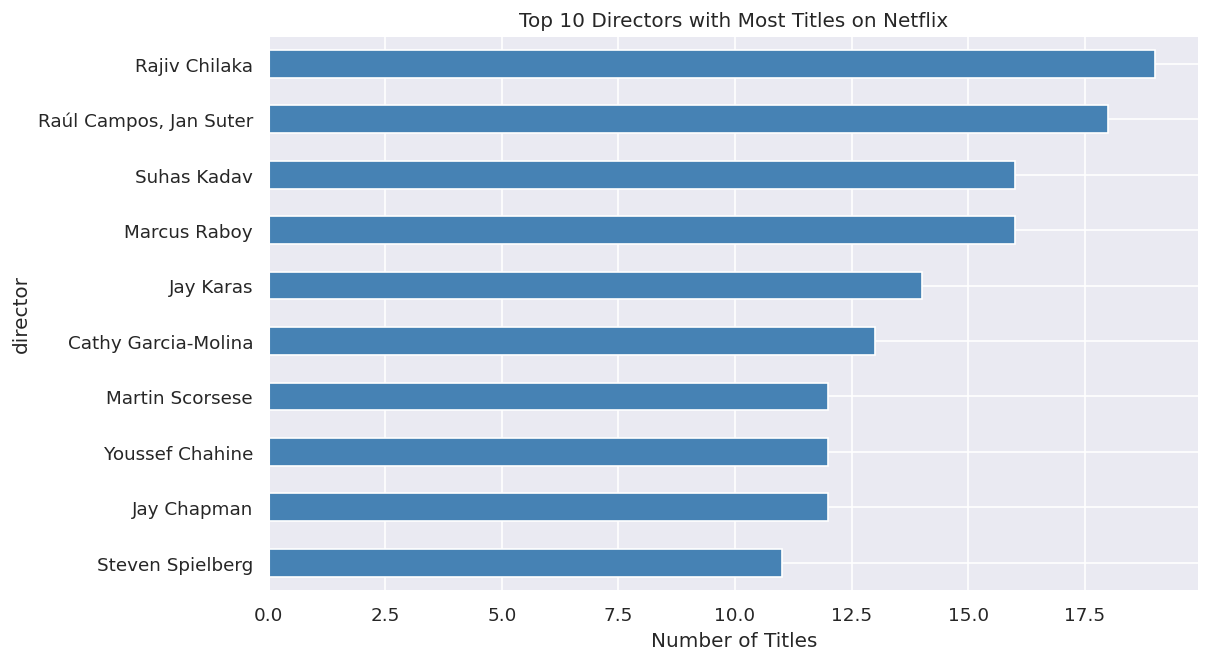

In [24]:
directors = df['director'].dropna()
directors.value_counts().head(10).plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Top 10 Directors with Most Titles on Netflix')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.show()

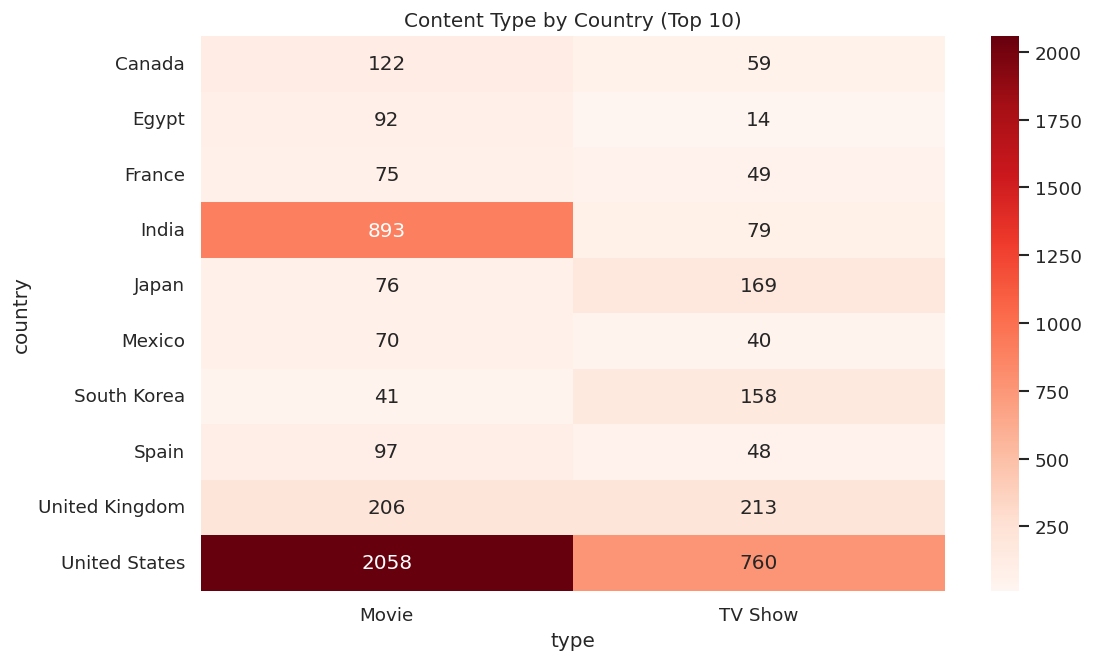

In [25]:
top_countries = df['country'].value_counts().head(10).index
df_top = df[df['country'].isin(top_countries)]

pivot = df_top.groupby(['country', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Reds')
plt.title('Content Type by Country (Top 10)')
plt.show()

## 🎬 Netflix Content Analysis

This notebook explores the Netflix dataset to understand content trends,
popular genres, top countries, and how the platform has evolved over the years.

**Dataset:** Netflix Movies and TV Shows — Kaggle
**Tools:** Python, Pandas, Matplotlib, Seaborn

/tmp/ipykernel_3719/1475524065.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='Reds_r')


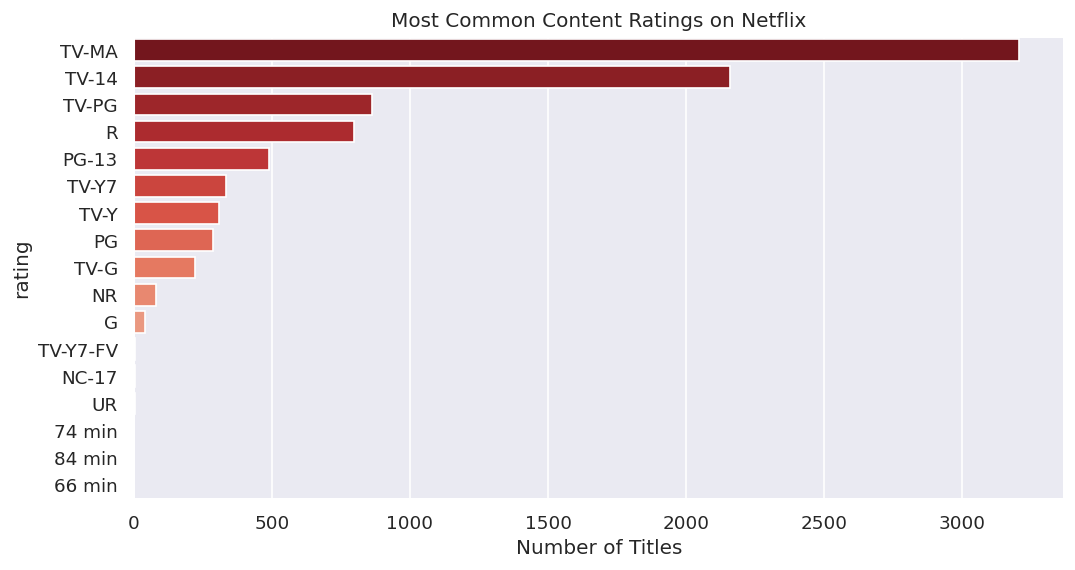

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='Reds_r')
plt.title('Most Common Content Ratings on Netflix')
plt.xlabel('Number of Titles')
plt.show()

### 📊 Key Insight — Ratings
Netflix's catalog is predominantly aimed at mature audiences,
with TV-MA and TV-14 being the most common ratings.
This reflects the platform's focus on adult-oriented content.

In [27]:
recent = df[df['year_added'] >= 2015]
print(f"Titles added after 2015: {len(recent)}")
print(f"That represents {round(len(recent)/len(df)*100, 1)}% of the entire catalog")

Titles added after 2015: 8741
That represents 99.3% of the entire catalog


### 📊 Key Insight — Growth
Netflix massively accelerated its content acquisition after 2015,
coinciding with its global expansion strategy.

/tmp/ipykernel_3719/1987997602.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='month_added', order=month_order, palette='Reds_r')


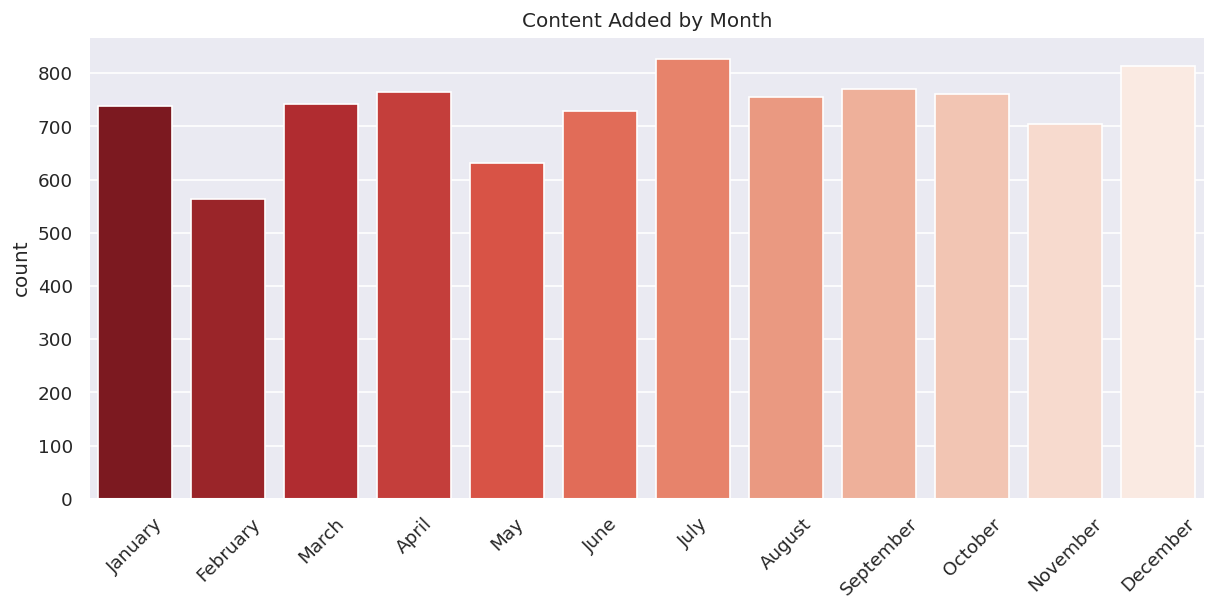

In [28]:
df['month_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce').dt.month_name()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='month_added', order=month_order, palette='Reds_r')
plt.title('Content Added by Month')
plt.xticks(rotation=45)
plt.xlabel('')
plt.show()

### 📊 Key Insight — Seasonality
Netflix tends to add more content in the last quarter of the year (October–January),
likely to retain subscribers during the holiday season.

/tmp/ipykernel_3719/917151173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movies_top, x='duration_min', y='country', palette='Reds_r')


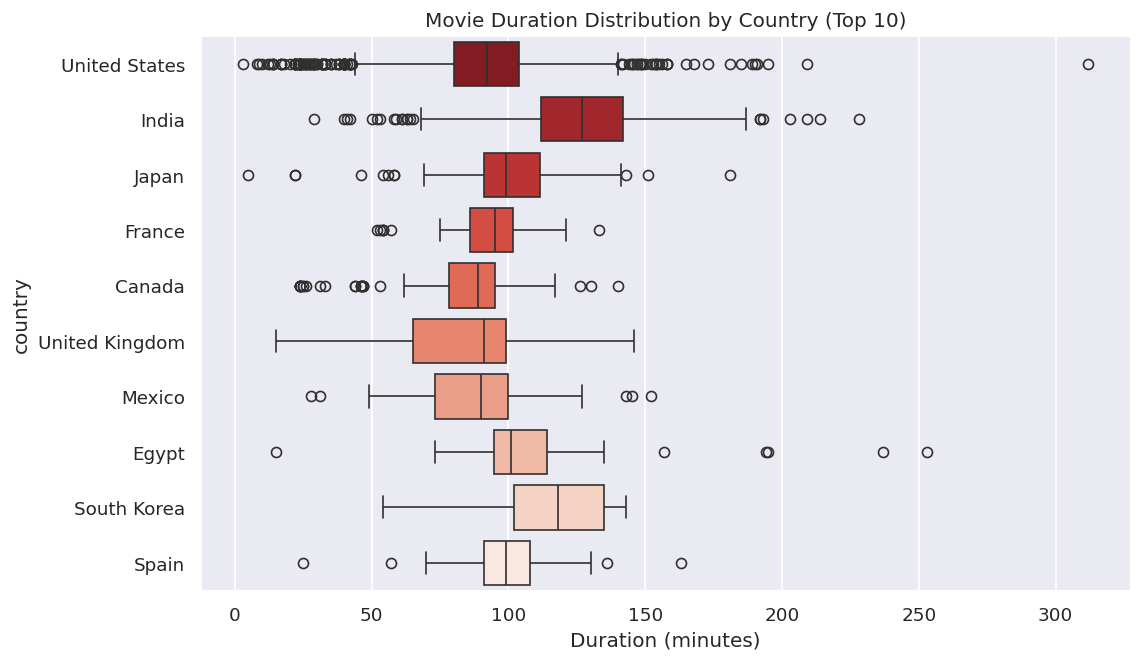

In [29]:
top10 = df['country'].value_counts().head(10).index
movies_top = df[(df['type'] == 'Movie') & (df['country'].isin(top10))].copy()
movies_top['duration_min'] = movies_top['duration'].str.replace(' min','').astype(float)

plt.figure(figsize=(10,6))
sns.boxplot(data=movies_top, x='duration_min', y='country', palette='Reds_r')
plt.title('Movie Duration Distribution by Country (Top 10)')
plt.xlabel('Duration (minutes)')
plt.show()

## ✅ Conclusions

- Netflix's catalog is dominated by **Movies** (~70%), but TV Shows have been growing steadily.
- The platform expanded rapidly after **2015**, adding thousands of titles globally.
- **United States, India and United Kingdom** produce the most content on the platform.
- The most common genres are **International Movies, Dramas and Comedies**.
- Content is heavily skewed toward **mature audiences** (TV-MA, TV-14).
- Netflix strategically adds more content in **Q4**, likely to reduce churn during holidays.

---
**Author:** Andressa P. Garbin  
**LinkedIn:** linkedin.com/in/andressa-garbin  
**GitHub:** github.com/andressa-garbin  
**Contact:** Florianópolis, SC — Brazil